## 1. Setup

In [32]:
import sys
from pathlib import Path

# Find the project root whether the notebook runs from root or notebooks/
ROOT = Path.cwd().resolve()
while not (ROOT / "src" / "data.py").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError(
            "Could not find src/data.py. Is src/data.py saved and non-empty?"
        )
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))
print("Project root:", ROOT)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load, FULL_PARQUET

FIGURE_DIR = ROOT/"reports/figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
data = load(sample=True)
data["hour"] = data["step"] % 24
print(data.shape)
data.dtypes

Project root: E:\Portifolio\MLs\mobile-money-fraud-triage
(636262, 12)


step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
hour                int64
dtype: object

In [33]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour
0,1,CASH_OUT,171369.73,C2123222442,0.00,0.00,C451111351,1122370.94,3940085.21,0,0,1
1,1,CASH_IN,55837.16,C713898436,4849053.05,4904890.21,C100555887,66800.82,10963.66,0,0,1
2,1,PAYMENT,2245.62,C194107588,30910.00,28664.38,M1264674474,0.00,0.00,0,0,1
3,1,CASH_OUT,39485.21,C626193099,0.00,0.00,C1883840933,9987286.56,16874643.09,0,0,1
4,1,PAYMENT,4975.75,C1377212248,2415.16,0.00,M1054477035,0.00,0.00,0,0,1


## 2. Class Imbalance

In [34]:
counts = data["isFraud"].value_counts()
print(counts)
print(f"Fraud Rate: {data['isFraud'].mean():.4%}")

# Why accuracy is useless here
print(f"'Predict no Fraud' accuracy : {1 - data['isFraud'].mean():.4%}")


isFraud
0    635445
1       817
Name: count, dtype: int64
Fraud Rate: 0.1284%
'Predict no Fraud' accuracy : 99.8716%


- The sample has 817 fraud cases among 636,262 transactions, so a model that always predicts `"no fraud"` would score 99.87% accuracy while catching zero fraud. 
- The sample only has 817 frauds, which is enough for exploring but thin for modelling. For the real modelling steps we'll use the full file, which has 8,213 fraud cases.

## Cell 3: fraud by transaction type (Figure 1)

In [35]:
by_type = data.groupby("type")["isFraud"].agg(["count", "sum", "mean"])
by_type.columns = ["transactions", "frauds", "fraud_rate"]
print(by_type)

          transactions  frauds  fraud_rate
type                                      
CASH_IN         139694       0    0.000000
CASH_OUT        223689     402    0.001797
DEBIT             4093       0    0.000000
PAYMENT         215342       0    0.000000
TRANSFER         53444     415    0.007765


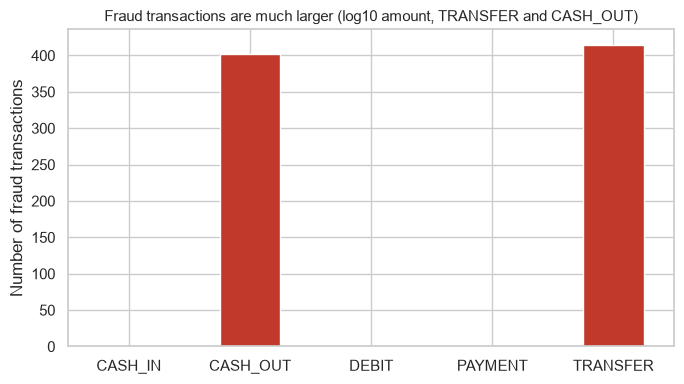

In [45]:
fig , ax = plt.subplots(figsize=(7,4))
by_type["frauds"].plot.bar(ax=ax, color='#c0392b')
ax.set_title("Fraud transactions are much larger (log10 amount, TRANSFER and CASH_OUT)", fontsize=11)
ax.set_ylabel("Number of fraud transactions")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "01_fraud_by_type.png", dpi=150)
plt.show()


- All 817 sample frauds are in TRANSFER (415) and CASH_OUT (402). The other three types have zero. That justifies restricting the model to those two types.

## Cell 4: fraud by hour (Figure 2)

In [37]:
by_hour = data.groupby("hour")["isFraud"].agg(["count", "sum", "mean"])
by_hour.columns = ["transactions", "frauds", "fraud_rate"]
by_hour

,transactions,frauds,fraud_rate
hour,,,
0,7013,29,0.004135
1,2715,33,0.012155
2,871,34,0.039036
3,188,30,0.159574
4,127,26,0.204724
5,174,49,0.281609
6,357,34,0.095238
7,876,27,0.030822
8,2720,32,0.011765


- In the rows shown (hours 0 to 9), the number of frauds stays roughly flat, 26 to 49 per hour. The fraud rate spikes to about 28% at hour 5 only because legitimate traffic nearly disappears overnight (127 to 174 transactions in hours 3 to 5, versus 28,008 at hour 9). 


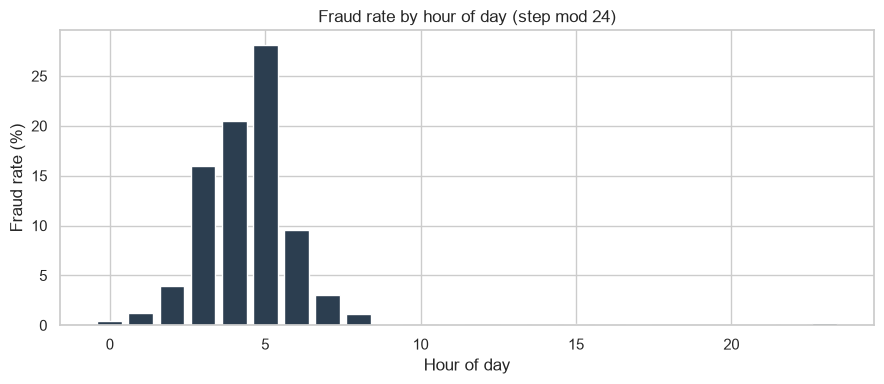

In [38]:
fig, ax = plt.subplots(figsize=(9,4))
ax.bar(by_hour.index, by_hour["fraud_rate"] * 100, color='#2c3e50')
ax.set_title("Fraud rate by hour of day (step mod 24)")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Fraud rate (%)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "02_fraud_by_hour.png", dpi=150)
plt.show()

## Cell 5: amount distribution (Figure 3)

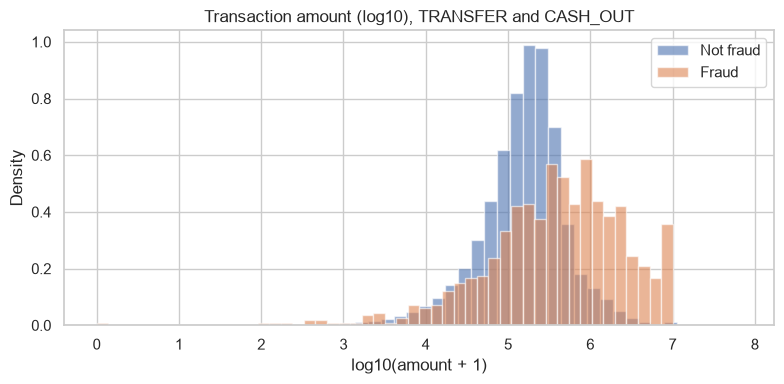

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,276316.0,3.171064e+05,8.939252e+05,0.01,82958.54,171788.615,3.066472e+05,69337316.27
1,817.0,1.361171e+06,2.235639e+06,0.00,127905.82,450060.370,1.433038e+06,10000000.00


In [39]:
sub = data[data["type"].isin(["TRANSFER", "CASH_OUT"])]

fig, ax = plt.subplots(figsize=(8, 4))
for label, grp in sub.groupby("isFraud"):
    ax.hist(np.log10(grp["amount"] + 1), bins=50, alpha=0.6, density=True,
            label="Fraud" if label else "Not fraud")
ax.set_title("Transaction amount (log10), TRANSFER and CASH_OUT")
ax.set_xlabel("log10(amount + 1)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "03_amount_distribution.png", dpi=150)
plt.show()

sub.groupby("isFraud")["amount"].describe()

## Cell 6: do account IDs repeat?

In [40]:
full = pd.read_parquet(FULL_PARQUET, columns=["nameOrig", "nameDest"])

for col in ["nameOrig", "nameDest"]:
    vc = full[col].value_counts()
    print(f"{col}: {len(vc):,} unique of {len(full):,} rows; "
          f"{(vc > 1).mean():.2%} of accounts appear more than once")

nameOrig: 6,353,307 unique of 6,362,620 rows; 0.15% of accounts appear more than once
nameDest: 2,722,362 unique of 6,362,620 rows; 16.88% of accounts appear more than once


- Only 0.15% of origin accounts appear more than once. That kills any per-sender history features, such as "how many transactions has this sender made recently", which the project plan asks for. Destination accounts repeat more (16.88%), but that is probably driven by merchants, so we'll test it later, restricted to TRANSFER and CASH_OUT.

## Cell 7: the balance leakage check

In [41]:
fr = data[data["type"].isin(["TRANSFER", "CASH_OUT"])].copy()
fr["orig_zeroed"] = fr["newbalanceOrig"] == 0
fr["orig_old_zero"] = fr["oldbalanceOrg"] == 0
fr["dest_old_zero"] = fr["oldbalanceDest"] == 0

print(fr.groupby("isFraud")[["orig_zeroed", "orig_old_zero", "dest_old_zero"]].mean())

         orig_zeroed  orig_old_zero  dest_old_zero
isFraud                                           
0           0.901338       0.473259       0.138320
1           0.985312       0.001224       0.670747


| In TRANSFER and CASH_OUT	  | Not fraud	  | Fraud        |
|-----------------------------|---------------|--------------|
| Origin's balance was 0 before	| 47.3%	| 0.1%  |
| Origin's balance is 0 after	| 90.1%	| 98.5% |
| Destination's balance was 0 before	| 13.8%	| 67.1%   |

Fraud almost always starts from an origin account with money in it and empties it. Half of the legitimate rows start from an account with a zero balance, which is odd and probably another simulator quirk. 

The pre-transaction balances therefore carry a lot of signal, but part of it comes from how PaySim was built. 

## Cell 8: test the leakage warning properly

In [42]:
fr = data[data["type"].isin(["TRANSFER", "CASH_OUT"])].copy()

fr["drains_account"] = np.isclose(fr["amount"], fr["oldbalanceOrg"])
fr["orig_err_nonzero"] = ~np.isclose(
    fr["newbalanceOrig"] + fr["amount"] - fr["oldbalanceOrg"], 0)
fr["dest_err_nonzero"] = ~np.isclose(
    fr["oldbalanceDest"] + fr["amount"] - fr["newbalanceDest"], 0)

cols = ["drains_account", "orig_err_nonzero", "dest_err_nonzero"]
print("All rows:")
print(fr.groupby("isFraud")[cols].mean())

print("\nOnly rows where origin had a positive balance:")
pos = fr[fr["oldbalanceOrg"] > 0]
print(pos.groupby("isFraud")[cols].mean())

All rows:
         drains_account  orig_err_nonzero  dest_err_nonzero
isFraud                                                    
0              0.000000          0.908138          0.288148
1              0.986536          0.001224          0.591187

Only rows where origin had a positive balance:
         drains_account  orig_err_nonzero  dest_err_nonzero
isFraud                                                    
0               0.00000          0.825603          0.257216
1               0.98652          0.001225          0.591912
